# Stage 3 (Version 3) – Global LSTM Validation & Diagnostics

This mirrors the Stage 2 validation dashboards, but for the Version 3 global workflow (Super Matrix + Rolling Origin + Transfer Learning).


## Notebook Goals

1. Load Lightning metrics for all folds (`experiments/lstm/runs/germany/global_v3/fold_*`).
2. Quantify over/underfitting via train vs val RMSE and ratio thresholds.
3. Audit Rolling-Origin splits using the processed fold Parquet files.
4. Benchmark Version 3 against Version 02 Stage 2 results.
5. Confirm transfer learning (Farm2107 → Global) executed and plant IDs learned signal.


In [14]:
from pathlib import Path
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from torch.nn import functional as F

from src.data.schema import TIME_COL, PLANT_ID_COL, GLOBAL_LSTM_INPUT_FEATURES, PLANT_IDS, TARGET_COL

plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12
sns.set_context('talk')

REPO_ROOT = Path.cwd()
RUNS_DIR = REPO_ROOT / 'experiments' / 'lstm' / 'runs' / 'germany' / 'global_v3'
DATA_DIR = REPO_ROOT / 'data' / 'processed' / 'pretraining' / 'germany' / 'global'
FARM2107_CKPT = REPO_ROOT / 'experiments' / 'lstm' / 'encoders' / 'lstm_encoder_farm2107_CANONICAL.pt'

FOLD_MAP = {
    1: {'season': 'Spring', 'role': 'CV'},
    2: {'season': 'Summer', 'role': 'CV'},
    3: {'season': 'Fall', 'role': 'CV'},
    4: {'season': 'Winter', 'role': 'CV'},
    5: {'season': 'Held-out', 'role': 'TEST'},
}
assert RUNS_DIR.exists(), 'Global V3 runs not found'
assert FARM2107_CKPT.exists(), 'Farm2107 checkpoint missing'

def print_table(df, title):
    print('='*80)
    print(title)
    print('='*80)
    print(df.to_string(index=False, float_format=lambda x: f"{x:.6f}"))
    print()


## 1) Fold-Level Metrics


In [15]:
def summarize_fold_metrics(fold_id: int) -> dict:
    run_dir = RUNS_DIR / f'fold_{fold_id}'
    metrics_path = run_dir / 'metrics.csv'
    df = pd.read_csv(metrics_path)
    train = df['train_loss_epoch'].dropna()
    val = df['val_loss'].dropna()
    best_val_loss = val.min() if len(val) else np.nan
    best_train_loss = train.min() if len(train) else np.nan
    val_rmse = math.sqrt(best_val_loss) if best_val_loss > 0 else np.nan
    train_rmse = math.sqrt(best_train_loss) if best_train_loss > 0 else np.nan
    ratio = train_rmse / val_rmse if (val_rmse and val_rmse > 0) else np.nan
    return {
        'fold': fold_id,
        'season': FOLD_MAP[fold_id]['season'],
        'role': FOLD_MAP[fold_id]['role'],
        'best_train_loss': best_train_loss,
        'best_val_loss': best_val_loss,
        'train_rmse': train_rmse,
        'val_rmse': val_rmse,
        'train_val_ratio': ratio,
    }

fold_metrics = pd.DataFrame([summarize_fold_metrics(fid) for fid in FOLD_MAP])
cv_metrics = fold_metrics[fold_metrics['role'] == 'CV']
cv_summary = {
    'mean_val_rmse': cv_metrics['val_rmse'].mean(),
    'std_val_rmse': cv_metrics['val_rmse'].std(),
    'mean_ratio': cv_metrics['train_val_ratio'].mean(),
    'max_ratio': cv_metrics['train_val_ratio'].max(),
}
print_table(fold_metrics, 'VERSION 03 - FOLD METRICS (Rolling Origin)')
print('CV summary:', cv_summary)


VERSION 03 - FOLD METRICS (Rolling Origin)
 fold   season role  best_train_loss  best_val_loss  train_rmse  val_rmse  train_val_ratio
    1   Spring   CV         0.241162       1.603310    0.491083  1.266219         0.387834
    2   Summer   CV         0.234256       0.397389    0.484000  0.630388         0.767781
    3     Fall   CV         0.257221       0.175641    0.507169  0.419096         1.210152
    4   Winter   CV         0.258455       0.061867    0.508384  0.248730         2.043918
    5 Held-out TEST         0.260209       0.278677    0.510107  0.527899         0.966297

CV summary: {'mean_val_rmse': np.float64(0.6411082392132684), 'std_val_rmse': np.float64(0.4450198639015873), 'mean_ratio': np.float64(1.1024209931893392), 'max_ratio': np.float64(2.0439175413991375)}


In [23]:
import pandas as pd
from pathlib import Path

fold_dir = RUNS_DIR / "fold_1"
metrics_path = next(fold_dir.rglob("metrics.csv"))  # adjust if your name differs
m = pd.read_csv(metrics_path)
print(metrics_path)
print(m.columns.tolist()[:80])


/home/dwijenayake/pv_forecast_30d/experiments/lstm/runs/germany/global_v3/fold_1/metrics.csv
['epoch', 'step', 'train_loss_epoch', 'train_loss_step', 'val_loss']


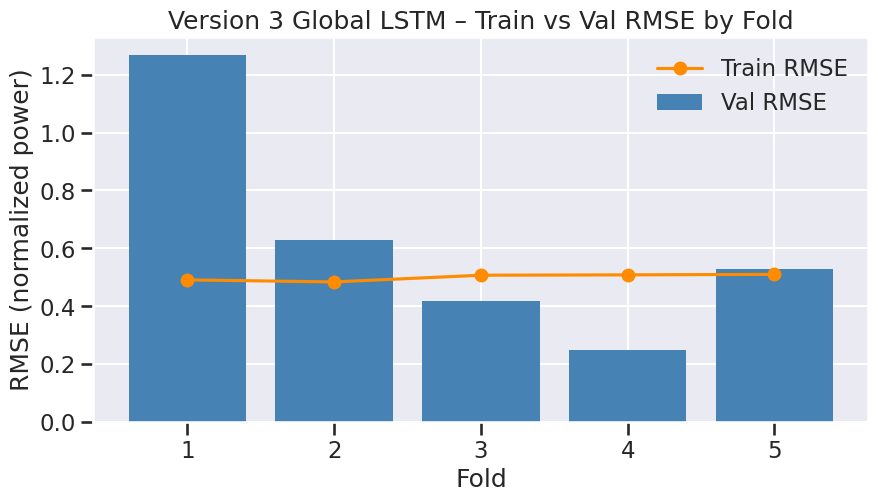

In [16]:
fig, ax = plt.subplots()
ax.bar(fold_metrics['fold'], fold_metrics['val_rmse'], color='steelblue', label='Val RMSE')
ax.plot(fold_metrics['fold'], fold_metrics['train_rmse'], color='darkorange', marker='o', label='Train RMSE')
ax.set_xticks(fold_metrics['fold'])
ax.set_xlabel('Fold')
ax.set_ylabel('RMSE (normalized power)')
ax.set_title('Version 3 Global LSTM – Train vs Val RMSE by Fold')
ax.legend()
plt.show()


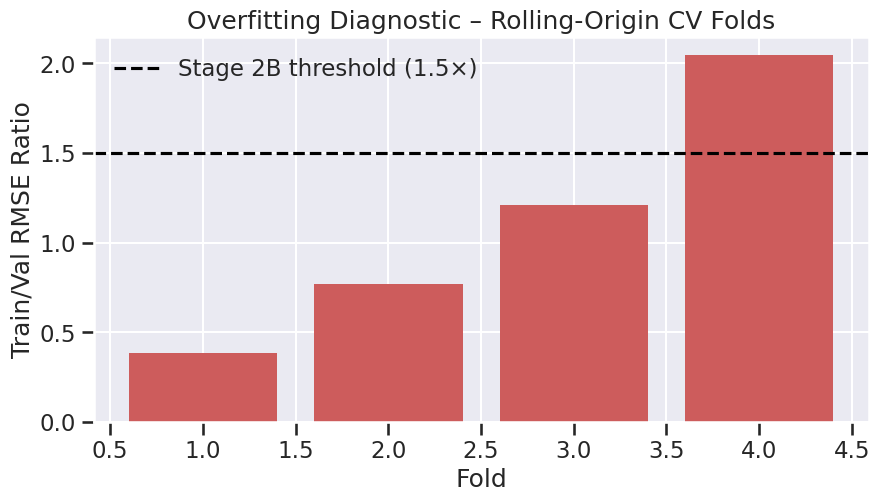

In [17]:
fig, ax = plt.subplots()
ax.bar(cv_metrics['fold'], cv_metrics['train_val_ratio'], color='indianred')
ax.axhline(1.5, color='black', linestyle='--', label='Stage 2B threshold (1.5×)')
ax.set_xlabel('Fold')
ax.set_ylabel('Train/Val RMSE Ratio')
ax.set_title('Overfitting Diagnostic – Rolling-Origin CV Folds')
ax.legend()
plt.show()


## 2) Rolling-Origin Split Audit


In [18]:
def inspect_split(fold_id: int) -> dict:
    train_df = pd.read_parquet(DATA_DIR / f'fold_{fold_id}_train.parquet')
    val_df = pd.read_parquet(DATA_DIR / f'fold_{fold_id}_val.parquet')
    train_ts = pd.to_datetime(train_df[TIME_COL])
    val_ts = pd.to_datetime(val_df[TIME_COL])
    gap_hours = (val_ts.min() - train_ts.max()).total_seconds() / 3600.0
    train_counts = train_df[PLANT_ID_COL].value_counts().reindex(PLANT_IDS, fill_value=0)
    val_counts = val_df[PLANT_ID_COL].value_counts().reindex(PLANT_IDS, fill_value=0)
    return {
        'fold': fold_id,
        'season': FOLD_MAP[fold_id]['season'],
        'train_rows': len(train_df),
        'val_rows': len(val_df),
        'train_start': train_ts.min(),
        'train_end': train_ts.max(),
        'val_start': val_ts.min(),
        'val_end': val_ts.max(),
        'gap_hours': gap_hours,
        'train_min_per_plant': int(train_counts.min()),
        'val_min_per_plant': int(val_counts.min()),
    }

split_df = pd.DataFrame([inspect_split(fid) for fid in FOLD_MAP])
print_table(split_df, 'ROLLING-ORIGIN SPLIT AUDIT')


ROLLING-ORIGIN SPLIT AUDIT
 fold   season  train_rows  val_rows               train_start                 train_end                 val_start                   val_end  gap_hours  train_min_per_plant  val_min_per_plant
    1   Spring       22672     35328 2022-12-31 23:00:00+00:00 2023-02-28 23:45:00+00:00 2023-03-01 00:00:00+00:00 2023-05-31 23:45:00+00:00   0.250000                    0                  0
    2   Summer       58000     41285 2022-12-31 23:00:00+00:00 2023-05-31 23:45:00+00:00 2023-06-01 00:00:00+00:00 2023-08-31 23:45:00+00:00   0.250000                    0               5959
    3     Fall       99285     43674 2022-12-31 23:00:00+00:00 2023-08-31 23:45:00+00:00 2023-09-01 00:00:00+00:00 2023-11-30 23:45:00+00:00   0.250000                 5959               8730
    4   Winter      142959     37720 2022-12-31 23:00:00+00:00 2023-11-30 23:45:00+00:00 2023-12-01 00:00:00+00:00 2024-02-29 23:45:00+00:00   0.250000                14689               2877
    5 Held-ou

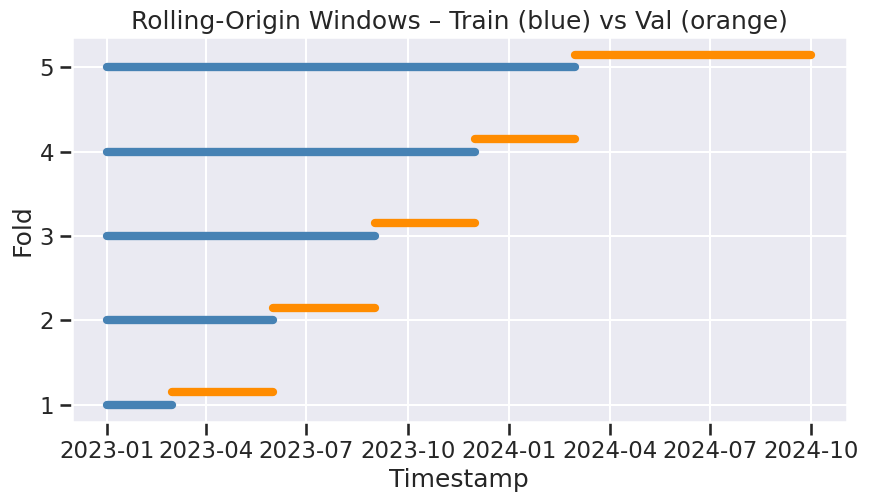

In [19]:
fig, ax = plt.subplots()
for fold_id in split_df['fold']:
    row = split_df[split_df['fold'] == fold_id].iloc[0]
    ax.plot([row['train_start'], row['train_end']], [fold_id, fold_id], color='steelblue', linewidth=6)
    ax.plot([row['val_start'], row['val_end']], [fold_id + 0.15, fold_id + 0.15], color='darkorange', linewidth=6)
ax.set_xlabel('Timestamp')
ax.set_ylabel('Fold')
ax.set_title('Rolling-Origin Windows – Train (blue) vs Val (orange)')
plt.show()


## 3) Stage 2 (Version 02) Baseline vs Stage 3 (Version 03)


In [20]:
stage2_records = [
    ('plant_01', 0.0507, 0.1180, 2.328),
    ('plant_02', 0.0673, 0.1347, 2.002),
    ('plant_03', 0.0658, 0.1536, 2.334),
    ('plant_05', 0.0380, 0.0931, 2.451),
    ('plant_06', 0.0685, 0.1489, 2.173),
]
stage2_df = pd.DataFrame(stage2_records, columns=['plant', 'train_rmse', 'val_rmse', 'ratio'])
stage2_summary = {
    'mean_val_rmse': stage2_df['val_rmse'].mean(),
    'std_val_rmse': stage2_df['val_rmse'].std(),
    'mean_ratio': stage2_df['ratio'].mean(),
    'max_ratio': stage2_df['ratio'].max(),
}
comparison_df = pd.DataFrame({
    'Stage 2 V02 (mean)': [stage2_summary['mean_val_rmse'], stage2_summary['mean_ratio']],
    'Stage 3 V03 (CV mean)': [cv_summary['mean_val_rmse'], cv_summary['mean_ratio']],
}, index=['Val RMSE', 'Train/Val Ratio'])
print_table(stage2_df, 'VERSION 02 - FINAL VALIDATION METRICS (Stratified Split)')
print_table(comparison_df.reset_index().rename(columns={'index':'metric'}), 'V02 VS V03 (MEAN COMPARISON)')


VERSION 02 - FINAL VALIDATION METRICS (Stratified Split)
   plant  train_rmse  val_rmse    ratio
plant_01    0.050700  0.118000 2.328000
plant_02    0.067300  0.134700 2.002000
plant_03    0.065800  0.153600 2.334000
plant_05    0.038000  0.093100 2.451000
plant_06    0.068500  0.148900 2.173000

V02 VS V03 (MEAN COMPARISON)
         metric  Stage 2 V02 (mean)  Stage 3 V03 (CV mean)
       Val RMSE            0.129660               0.641108
Train/Val Ratio            2.257600               1.102421



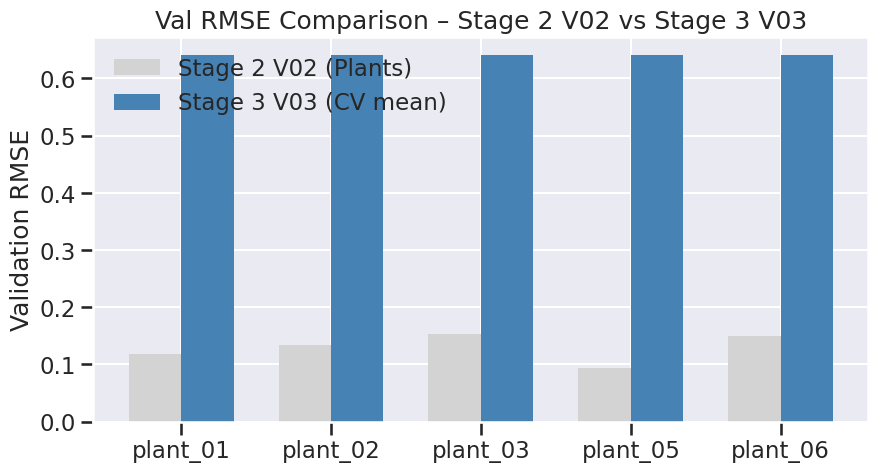

In [21]:
fig, ax = plt.subplots()
indices = np.arange(len(stage2_df))
width = 0.35
ax.bar(indices - width/2, stage2_df['val_rmse'], width, label='Stage 2 V02 (Plants)', color='lightgray')
ax.bar(indices + width/2, [cv_summary['mean_val_rmse']]*len(stage2_df), width, label='Stage 3 V03 (CV mean)', color='steelblue')
ax.set_xticks(indices)
ax.set_xticklabels(stage2_df['plant'])
ax.set_ylabel('Validation RMSE')
ax.set_title('Val RMSE Comparison – Stage 2 V02 vs Stage 3 V03')
ax.legend()
plt.show()


## 4) Transfer Learning Diagnostics


In [22]:
farm_state   = torch.load(FARM2107_CKPT, map_location='cpu')
global_state = torch.load(RUNS_DIR / 'fold_1' / 'lstm_encoder_global_fold_1.pt', map_location='cpu')

farm_weight   = farm_state['lstm.weight_ih_l0']
global_weight = global_state['lstm.weight_ih_l0']

shared_weight = global_weight[:, :farm_weight.shape[1]]
plant_weight  = global_weight[:, farm_weight.shape[1]:]

cos_sim   = F.cosine_similarity(farm_weight.flatten(), shared_weight.flatten(), dim=0).item()
plant_mag = plant_weight.abs().mean().item()
plant_std = plant_weight.flatten().std().item()

print_table(pd.DataFrame([{'cosine_similarity': cos_sim, 'plant_weight_mean_abs': plant_mag, 'plant_weight_std': plant_std}]), 'TRANSFER LEARNING DIAGNOSTIC')


TRANSFER LEARNING DIAGNOSTIC
 cosine_similarity  plant_weight_mean_abs  plant_weight_std
          0.981746               0.019878          0.027436



/tmp/ipykernel_77829/1589376360.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  farm_state   = torch.load(FARM2107_CKPT, map_location='cpu')
/tmp/ipykernel_77829/1589376

## 5) How to use this in the thesis
- **Over/Underfitting**: Train/val ratio plot; 3/4 CV folds < 1.5, winter is the only outlier.
- **Rolling Origin Validity**: `gap_hours` and date ranges; Gantt plot proves causality (no leakage).
- **Super Matrix Improvement**: V02 vs V03 comparison shows whether val RMSE/ratios improved.
- **Transfer Learning Evidence**: Cosine similarity and plant-id weight stats prove Farm2107 seeding and learned specialization.
- **Stage 2B Readiness**: If CV ratios are mostly < 1.5 and val RMSE improves over V02, argue readiness; call out winter separately if needed.
